# E-commerce Purchase Prediction — LightGBM v2
### Prédire qui va acheter dans les 3 prochains jours à partir du comportement observé

**Dataset:** [eCommerce Behavior Data](https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store)

**Workflow corrigé :**
1. **Observation period** (1-14 Oct) → on construit les features par user
2. **Prediction period** (15-18 Oct) → on crée le label `y` (a acheté ou non)
3. Les features ne contiennent **aucune info de la période de prédiction** → pas de target leakage

> **Changement clé vs v1 :** Dans le notebook précédent, le label `y` était construit
> sur la **même période** que les features → le modèle "lisait" la réponse dans
> `total_purchases` / `has_ever_purchased`. Ici, les deux périodes sont strictement séparées.


# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, recall_score
)

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
print("Imports OK")


/Users/adrien/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


# 2. Chargement des données

In [2]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mkechinov/ecommerce-behavior-data-from-multi-category-store",
    "2019-Oct.csv",
    pandas_kwargs={
        "nrows": 10_000_000,
        "dtype": {
            "event_type": "category",
            "product_id": "int32",
            "category_code": "category",
            "brand": "category",
            "price": "float32",
            "user_id": "int32",
        }
    }
)
print(f"Shape: {df.shape}")
df.head()


Shape: (10000000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


# 3. Nettoyage de base

In [3]:
# Parse event_time
df["event_time"] = pd.to_datetime(
    df["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

# Remplir les NaN de brand et category_code
df["brand"] = df["brand"].astype(str).replace("nan", "unknown").astype("category")
df["category_code"] = df["category_code"].astype(str).replace("nan", "unknown").astype("category")

# Flag brand connue
df["has_brand"] = (df["brand"] != "unknown").astype("int8")

# Supprimer les doublons
n_before = len(df)
df = df.drop_duplicates()
print(f"Doublons supprimes : {n_before - len(df):,}")

# Verifier la plage temporelle
print(f"Periode : {df['event_time'].min()} -> {df['event_time'].max()}")
print(f"Shape finale : {df.shape}")


Doublons supprimes : 6,213
Periode : 2019-10-01 00:00:00 -> 2019-10-08 17:26:09
Shape finale : (9993787, 10)


# 4. Filtrage sur les top catégories

On garde les catégories avec le plus d'achats pour concentrer le signal.

In [4]:
# Compter les achats par categorie
purchase_counts = (
    df[df["event_type"] == "purchase"]
    .groupby("category_code")
    .size()
    .sort_values(ascending=False)
)

# Afficher le top 20
print("Top 20 categories par nombre d'achats :\n")
print(purchase_counts.head(20))
print(f"\nTotal categories avec achats : {(purchase_counts > 0).sum()}")


Top 20 categories par nombre d'achats :

category_code
electronics.smartphone                 79201
unknown                                39621
electronics.audio.headphone             7257
electronics.video.tv                    4848
electronics.clocks                      4495
computers.notebook                      3914
appliances.kitchen.washer               3703
appliances.environment.vacuum           2835
appliances.kitchen.refrigerators        2439
auto.accessories.player                 1547
electronics.tablet                      1218
electronics.audio.subwoofer             1041
appliances.iron                          868
appliances.environment.air_heater        836
electronics.telephone                    829
appliances.kitchen.microwave             818
computers.desktop                        746
auto.accessories.videoregister           719
appliances.environment.water_heater      710
auto.accessories.alarm                   697
dtype: int64

Total categories avec achats : 

In [5]:
# Garder le top 15 (hors "unknown")
top_categories = (
    purchase_counts[purchase_counts.index != "unknown"]
    .head(15)
    .index
    .tolist()
)

print(f"Categories retenues ({len(top_categories)}) :")
for i, cat in enumerate(top_categories, 1):
    print(f"  {i:2d}. {cat} ({purchase_counts[cat]:,} achats)")

df_filtered = df[df["category_code"].isin(top_categories)].copy()
print(f"\nLignes retenues : {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}% du total)")


Categories retenues (15) :
   1. electronics.smartphone (79,201 achats)
   2. electronics.audio.headphone (7,257 achats)
   3. electronics.video.tv (4,848 achats)
   4. electronics.clocks (4,495 achats)
   5. computers.notebook (3,914 achats)
   6. appliances.kitchen.washer (3,703 achats)
   7. appliances.environment.vacuum (2,835 achats)
   8. appliances.kitchen.refrigerators (2,439 achats)
   9. auto.accessories.player (1,547 achats)
  10. electronics.tablet (1,218 achats)
  11. electronics.audio.subwoofer (1,041 achats)
  12. appliances.iron (868 achats)
  13. appliances.environment.air_heater (836 achats)
  14. electronics.telephone (829 achats)
  15. appliances.kitchen.microwave (818 achats)

Lignes retenues : 4,976,200 (49.8% du total)


# 5. Séparation observation / prédiction

C'est le coeur de la méthodologie. On coupe le temps en deux :

- **Observation** (1 Oct → 14 Oct minuit) : on regarde le comportement passé → **features**
- **Prédiction** (15 Oct → 18 Oct) : on regarde qui achète → **label y**

La période d'observation est plus longue que dans le notebook v1 (14 jours vs 5 jours).
Plus de données = features plus stables et plus d'utilisateurs couverts.


In [6]:
observation_end = pd.Timestamp("2019-10-05")  # exclu (< strict)
prediction_end  = pd.Timestamp("2019-10-08")  # exclu

X_obs  = df_filtered[df_filtered["event_time"] < observation_end].copy()
X_pred = df_filtered[
    (df_filtered["event_time"] >= observation_end) &
    (df_filtered["event_time"] < prediction_end)
].copy()

print(f"X_obs  : {len(X_obs):>10,} events | {X_obs['user_id'].nunique():>8,} users | "
      f"{X_obs['event_time'].min().date()} -> {X_obs['event_time'].max().date()}")
print(f"X_pred : {len(X_pred):>10,} events | {X_pred['user_id'].nunique():>8,} users | "
      f"{X_pred['event_time'].min().date()} -> {X_pred['event_time'].max().date()}")


X_obs  :  2,530,043 events |  378,301 users | 2019-10-01 -> 2019-10-04
X_pred :  1,924,932 events |  295,171 users | 2019-10-05 -> 2019-10-07


# 6. Création du label y

Le label vient **uniquement** de la période de prédiction.
On ne peut prédire que pour les users qu'on a **observés** pendant la période d'observation.


In [7]:
# Users qui achetent pendant la periode de prediction
purchasers_pred = set(
    X_pred.loc[X_pred["event_type"] == "purchase", "user_id"]
)

# Tous les users observes pendant la periode d'observation
observed_users = X_obs["user_id"].unique()

# Construire y : 1 user = 1 ligne
y_df = pd.DataFrame({"user_id": observed_users})
y_df["label"] = y_df["user_id"].isin(purchasers_pred).astype(int)

print(f"Users observes : {len(y_df):,}")
print(f"Acheteurs dans la periode de prediction : {len(purchasers_pred):,}")
print(f"  -> dont observes dans X_obs : {y_df['label'].sum():,}")
print(f"  -> non observes (perdus) : {len(purchasers_pred) - y_df['label'].sum():,}")
print(f"\nBalance des classes :")
print(y_df["label"].value_counts())
print(f"\nTaux de positifs : {y_df['label'].mean()*100:.2f}%")


Users observes : 378,301
Acheteurs dans la periode de prediction : 29,356
  -> dont observes dans X_obs : 11,090
  -> non observes (perdus) : 18,266

Balance des classes :
label
0    367211
1     11090
Name: count, dtype: int64

Taux de positifs : 2.93%


# 7. Feature Engineering

Toutes les features sont calculées **exclusivement** sur X_obs.
On regroupe par user_id pour obtenir un vecteur de features par utilisateur.


## 7.1 Colonnes temporelles de base

In [8]:
X_obs["hour"] = X_obs["event_time"].dt.hour
X_obs["dayofweek"] = X_obs["event_time"].dt.dayofweek  # 0=lundi
X_obs["is_weekend"] = (X_obs["dayofweek"] >= 5).astype("int8")
X_obs["day"] = X_obs["event_time"].dt.day
print("Colonnes temporelles ajoutees")


Colonnes temporelles ajoutees


## 7.2 Features de comportement global

Comptages des différents types d'events par user.

**Note :** `total_purchases` et `has_ever_purchased` sont gardés ici car le label
vient d'une **autre période**. Ce n'est plus du leakage : c'est de l'info historique
légitime ("un user qui a déjà acheté a plus de chances de racheter").


In [9]:
behavior = X_obs.groupby("user_id").agg(
    total_events    = ("event_type", "count"),
    total_views     = ("event_type", lambda x: (x == "view").sum()),
    total_carts     = ("event_type", lambda x: (x == "cart").sum()),
    total_purchases = ("event_type", lambda x: (x == "purchase").sum()),
    n_sessions      = ("user_session", "nunique"),
    n_days_active   = ("event_time", lambda x: x.dt.date.nunique()),
)

# Ratios
behavior["view_to_cart_ratio"] = (
    behavior["total_carts"] / behavior["total_views"].replace(0, 1)
)
behavior["cart_to_purchase_ratio"] = (
    behavior["total_purchases"] / behavior["total_carts"].replace(0, 1)
)
behavior["events_per_day"] = (
    behavior["total_events"] / behavior["n_days_active"].replace(0, 1)
)

# Flags binaires
behavior["has_ever_carted"]    = (behavior["total_carts"] > 0).astype("int8")
behavior["has_ever_purchased"] = (behavior["total_purchases"] > 0).astype("int8")

print(f"behavior shape: {behavior.shape}")
behavior.head()


behavior shape: (378301, 11)


,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,view_to_cart_ratio,cart_to_purchase_ratio,events_per_day,has_ever_carted,has_ever_purchased
user_id,,,,,,,,,,,
241587569,1,1,0,0,1,1,0.0,0.0,1.0,0,0
241784978,1,1,0,0,1,1,0.0,0.0,1.0,0,0
244951053,5,5,0,0,2,2,0.0,0.0,2.5,0,0
277067319,6,6,0,0,1,1,0.0,0.0,6.0,0,0
293335683,12,12,0,0,3,1,0.0,0.0,12.0,0,0


## 7.3 Features de session

On calcule les stats de session, puis on agrège par user.
On filtre les sessions anormalement longues (>18h) = sessions "zombies" laissées ouvertes.


In [10]:
# Stats par session
session_stats = X_obs.groupby(["user_id", "user_session"], as_index=False).agg(
    session_start  = ("event_time", "min"),
    session_end    = ("event_time", "max"),
    session_events = ("event_time", "count"),
)
session_stats["session_duration_sec"] = (
    (session_stats["session_end"] - session_stats["session_start"]).dt.total_seconds()
)

# Filtrer les sessions > 18h
n_long = (session_stats["session_duration_sec"] > 18*3600).sum()
print(f"Sessions > 18h supprimees : {n_long:,}")
session_stats = session_stats[session_stats["session_duration_sec"] <= 18*3600]

# Agregation par user
session_user = session_stats.groupby("user_id").agg(
    avg_session_duration    = ("session_duration_sec", "mean"),
    median_session_duration = ("session_duration_sec", "median"),
    max_session_duration    = ("session_duration_sec", "max"),
    total_sessions_clean    = ("user_session", "count"),
    avg_events_per_session  = ("session_events", "mean"),
    max_events_per_session  = ("session_events", "max"),
)

print(f"session_user shape: {session_user.shape}")
session_user.head()


Sessions > 18h supprimees : 1,297
session_user shape: (377531, 6)


,avg_session_duration,median_session_duration,max_session_duration,total_sessions_clean,avg_events_per_session,max_events_per_session
user_id,,,,,,
241587569,0.000000,0.0,0.0,1,1.0,1
241784978,0.000000,0.0,0.0,1,1.0,1
244951053,91.000000,91.0,129.0,2,2.5,3
277067319,228.000000,228.0,228.0,1,6.0,6
293335683,304.333333,275.0,548.0,3,4.0,6


## 7.4 Features de récence

La récence est souvent l'un des meilleurs prédicteurs en marketing :
un user actif récemment a plus de chances de revenir acheter.

`recency_days` = jours entre le **dernier event** de l'user et la fin de l'observation.
Plus c'est petit, plus l'user est "chaud".


In [11]:
temporal = X_obs.groupby("user_id").agg(
    last_event_ts   = ("event_time", "max"),
    first_event_ts  = ("event_time", "min"),
    preferred_hour  = ("hour", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 12),
    weekend_ratio   = ("is_weekend", "mean"),
)

# Recence : jours depuis le dernier event jusqu'a la fin de l'observation
temporal["recency_days"] = (
    (observation_end - temporal["last_event_ts"]).dt.total_seconds() / 86400
)

# Anciennete : duree totale de presence dans l'observation
temporal["tenure_days"] = (
    (temporal["last_event_ts"] - temporal["first_event_ts"]).dt.total_seconds() / 86400
)

# Convertir timestamps en float pour le modele
temporal["last_event_ts"]  = temporal["last_event_ts"].astype("int64") / 10**9
temporal["first_event_ts"] = temporal["first_event_ts"].astype("int64") / 10**9

print(f"temporal shape: {temporal.shape}")
temporal.head()


temporal shape: (378301, 6)


,last_event_ts,first_event_ts,preferred_hour,weekend_ratio,recency_days,tenure_days
user_id,,,,,,
241587569,1.570016e+09,1.570016e+09,11,0.0,2.522060,0.000000
241784978,1.570176e+09,1.570176e+09,8,0.0,0.666586,0.000000
244951053,1.570072e+09,1.569920e+09,3,0.0,1.869132,1.764491
277067319,1.569986e+09,1.569986e+09,3,0.0,2.863796,0.002639
293335683,1.570039e+09,1.569990e+09,4,0.0,2.249618,0.565602


## 7.5 Features de diversité produit

In [12]:
diversity = X_obs.groupby("user_id").agg(
    unique_products   = ("product_id", "nunique"),
    unique_categories = ("category_id", "nunique"),
    unique_brands     = ("brand", "nunique"),
)

# Taux de revisites : si un user revoit souvent les memes produits
diversity["product_revisit_rate"] = 1 - (
    diversity["unique_products"] / behavior["total_events"].replace(0, 1)
)

print(f"diversity shape: {diversity.shape}")
diversity.head()


diversity shape: (378301, 4)


,unique_products,unique_categories,unique_brands,product_revisit_rate
user_id,,,,
241587569,1,1,1,0.000000
241784978,1,1,1,0.000000
244951053,3,1,2,0.400000
277067319,4,1,4,0.333333
293335683,3,1,1,0.750000


## 7.6 Features de prix

In [13]:
price_feats = X_obs.groupby("user_id")["price"].agg(
    avg_price    = "mean",
    median_price = "median",
    max_price    = "max",
    min_price    = "min",
    std_price    = "std",
)

price_feats["price_range"] = price_feats["max_price"] - price_feats["min_price"]

# std_price = NaN pour les users avec 1 seul event
price_feats["std_price"] = price_feats["std_price"].fillna(0)

print(f"price_feats shape: {price_feats.shape}")
price_feats.head()


price_feats shape: (378301, 6)


,avg_price,median_price,max_price,min_price,std_price,price_range
user_id,,,,,,
241587569,130.250000,130.250000,130.250000,130.250000,0.000000,0.000000
241784978,462.380005,462.380005,462.380005,462.380005,0.000000,0.000000
244951053,759.712036,731.039978,1415.479980,460.500000,390.746552,954.979980
277067319,189.039993,163.380005,334.600006,69.139999,127.764648,265.460022
293335683,529.153381,447.744995,720.460022,370.410004,174.304977,350.050018


## 7.7 Features d'engagement "funnel" (nouveau)

Mesure la progression de chaque user dans le funnel view → cart → purchase.
Un user qui a mis au panier récemment est un signal fort d'achat imminent.

**`days_since_last_cart`** est souvent très prédictif : quelqu'un qui a ajouté au panier
il y a 1 jour a beaucoup plus de chances d'acheter que quelqu'un qui l'a fait il y a 10 jours.


In [14]:
# Encoder le type d'event en rang dans le funnel : view=0, cart=1, purchase=2
event_rank = {"view": 0, "cart": 1, "purchase": 2}
X_obs["event_rank"] = X_obs["event_type"].map(event_rank).astype("int8")

funnel = X_obs.groupby("user_id").agg(
    max_funnel_stage  = ("event_rank", "max"),   # Jusqu'ou l'user est alle
    last_event_stage  = ("event_rank", "last"),   # Son dernier event
)

# Recence du dernier cart (jours avant la fin de l'observation)
last_cart = (
    X_obs[X_obs["event_type"] == "cart"]
    .groupby("user_id")["event_time"]
    .max()
)
funnel["days_since_last_cart"] = (
    (observation_end - last_cart).dt.total_seconds() / 86400
)
# Users sans cart -> valeur haute (= pas de signal cart)
funnel["days_since_last_cart"] = funnel["days_since_last_cart"].fillna(999)

# Recence du dernier achat
last_purchase = (
    X_obs[X_obs["event_type"] == "purchase"]
    .groupby("user_id")["event_time"]
    .max()
)
funnel["days_since_last_purchase"] = (
    (observation_end - last_purchase).dt.total_seconds() / 86400
)
funnel["days_since_last_purchase"] = funnel["days_since_last_purchase"].fillna(999)

print(f"funnel shape: {funnel.shape}")
funnel.head()


funnel shape: (378301, 4)


,max_funnel_stage,last_event_stage,days_since_last_cart,days_since_last_purchase
user_id,,,,
241587569,0,0,999.0,999.0
241784978,0,0,999.0,999.0
244951053,0,0,999.0,999.0
277067319,0,0,999.0,999.0
293335683,0,0,999.0,999.0


## 7.8 Features de tendance (nouveau)

On compare l'activité de la **2e moitié** de l'observation vs la **1re moitié**.

- `activity_trend > 1` → le user accélère son activité (signal positif)
- `activity_trend < 1` → le user se désintéresse
- `activity_trend ≈ 1` → activité stable

On ajoute +1 au numérateur et dénominateur (lissage de Laplace) pour éviter la division par 0
et ne pas donner un trend infini à un user apparu uniquement en 2e moitié.


In [15]:
# Couper l'observation en deux moities
obs_midpoint = X_obs["event_time"].min() + (observation_end - X_obs["event_time"].min()) / 2

first_half  = X_obs[X_obs["event_time"] < obs_midpoint].groupby("user_id").size()
second_half = X_obs[X_obs["event_time"] >= obs_midpoint].groupby("user_id").size()

# Combiner
trend = pd.DataFrame({
    "events_first_half":  first_half,
    "events_second_half": second_half,
}).fillna(0)

# Ratio avec lissage de Laplace (+1)
trend["activity_trend"] = (
    (trend["events_second_half"] + 1) / (trend["events_first_half"] + 1)
)

# Ne garder que le trend
trend = trend[["activity_trend"]]

print(f"trend shape: {trend.shape}")
trend.describe()


trend shape: (378301, 1)


,activity_trend
count,378301.000000
mean,3.298178
std,6.459046
min,0.002188
25%,0.333333
50%,1.500000
75%,4.000000
max,247.000000


## 7.9 Features de marque (nouveau)

In [16]:
brand_feats = X_obs.groupby("user_id").agg(
    brand_known_ratio = ("has_brand", "mean"),  # % d'events sur produits avec marque connue
)

print(f"brand_feats shape: {brand_feats.shape}")
brand_feats.head()


brand_feats shape: (378301, 1)


,brand_known_ratio
user_id,
241587569,1.000000
241784978,1.000000
244951053,1.000000
277067319,0.666667
293335683,1.000000


# 8. Assemblage du dataset final

In [17]:
# Joindre toutes les features par user_id
user_features = (
    behavior
    .join(session_user,  how="left")
    .join(diversity,     how="left")
    .join(price_feats,   how="left")
    .join(temporal,      how="left")
    .join(funnel,        how="left")
    .join(trend,         how="left")
    .join(brand_feats,   how="left")
)

print(f"user_features shape: {user_features.shape}")
nan_cols = user_features.isna().sum()
print(f"Colonnes avec NaN :\n{nan_cols[nan_cols > 0]}")


user_features shape: (378301, 39)
Colonnes avec NaN :
avg_session_duration       770
median_session_duration    770
max_session_duration       770
total_sessions_clean       770
avg_events_per_session     770
max_events_per_session     770
dtype: int64


In [18]:
# Merge features + labels
dataset = y_df.merge(user_features, on="user_id", how="inner")

print(f"Dataset final : {dataset.shape}")
print(f"Positifs (acheteurs) : {dataset['label'].sum():,} ({dataset['label'].mean()*100:.2f}%)")
print(f"Negatifs : {(dataset['label']==0).sum():,}")


Dataset final : (378301, 41)
Positifs (acheteurs) : 11,090 (2.93%)
Negatifs : 367,211


In [19]:
# Separer X et y
y = dataset["label"]
X = dataset.drop(columns=["label", "user_id"])

# Remplir les NaN restants (users sans session valide apres filtrage, etc.)
X = X.fillna(0)

print(f"X shape: {X.shape}")
print(f"\nFeatures ({X.shape[1]}) :")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


X shape: (378301, 39)

Features (39) :
   1. total_events
   2. total_views
   3. total_carts
   4. total_purchases
   5. n_sessions
   6. n_days_active
   7. view_to_cart_ratio
   8. cart_to_purchase_ratio
   9. events_per_day
  10. has_ever_carted
  11. has_ever_purchased
  12. avg_session_duration
  13. median_session_duration
  14. max_session_duration
  15. total_sessions_clean
  16. avg_events_per_session
  17. max_events_per_session
  18. unique_products
  19. unique_categories
  20. unique_brands
  21. product_revisit_rate
  22. avg_price
  23. median_price
  24. max_price
  25. min_price
  26. std_price
  27. price_range
  28. last_event_ts
  29. first_event_ts
  30. preferred_hour
  31. weekend_ratio
  32. recency_days
  33. tenure_days
  34. max_funnel_stage
  35. last_event_stage
  36. days_since_last_cart
  37. days_since_last_purchase
  38. activity_trend
  39. brand_known_ratio


# 9. Train / Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Train : {len(X_train):,} ({y_train.sum():,} positifs)")
print(f"Test  : {len(X_test):,} ({y_test.sum():,} positifs)")
print(f"scale_pos_weight : {scale_pos_weight:.1f}")


Train : 302,640 (8,872 positifs)
Test  : 75,661 (2,218 positifs)
scale_pos_weight : 33.1


# 10. Modèle baseline (LightGBM par défaut)

On commence par un modèle avec les hyperparamètres par défaut pour avoir une référence.

In [21]:
model_baseline = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)

model_baseline.fit(X_train, y_train)

y_proba_base = model_baseline.predict_proba(X_test)[:, 1]
y_pred_base  = (y_proba_base >= 0.5).astype(int)

roc_base = roc_auc_score(y_test, y_proba_base)
pr_base  = average_precision_score(y_test, y_proba_base)
rec_base = recall_score(y_test, y_pred_base)

print("=== BASELINE ===")
print(f"ROC AUC     : {roc_base:.4f}")
print(f"PR AUC      : {pr_base:.4f}")
print(f"Recall @0.5 : {rec_base:.4f}")
print()
print(classification_report(y_test, y_pred_base))


=== BASELINE ===
ROC AUC     : 0.7655
PR AUC      : 0.2043
Recall @0.5 : 0.5307

              precision    recall  f1-score   support

           0       0.98      0.88      0.93     73443
           1       0.11      0.53      0.19      2218

    accuracy                           0.87     75661
   macro avg       0.55      0.70      0.56     75661
weighted avg       0.96      0.87      0.90     75661



### Interpréter les résultats baseline

Si le PR AUC est entre **0.05 et 0.30**, c'est normal pour ce type de problème
(taux de positifs très faible ~2-5%). Si c'est proche de 1.0, il y a encore du
leakage quelque part.


# 11. Feature Importance

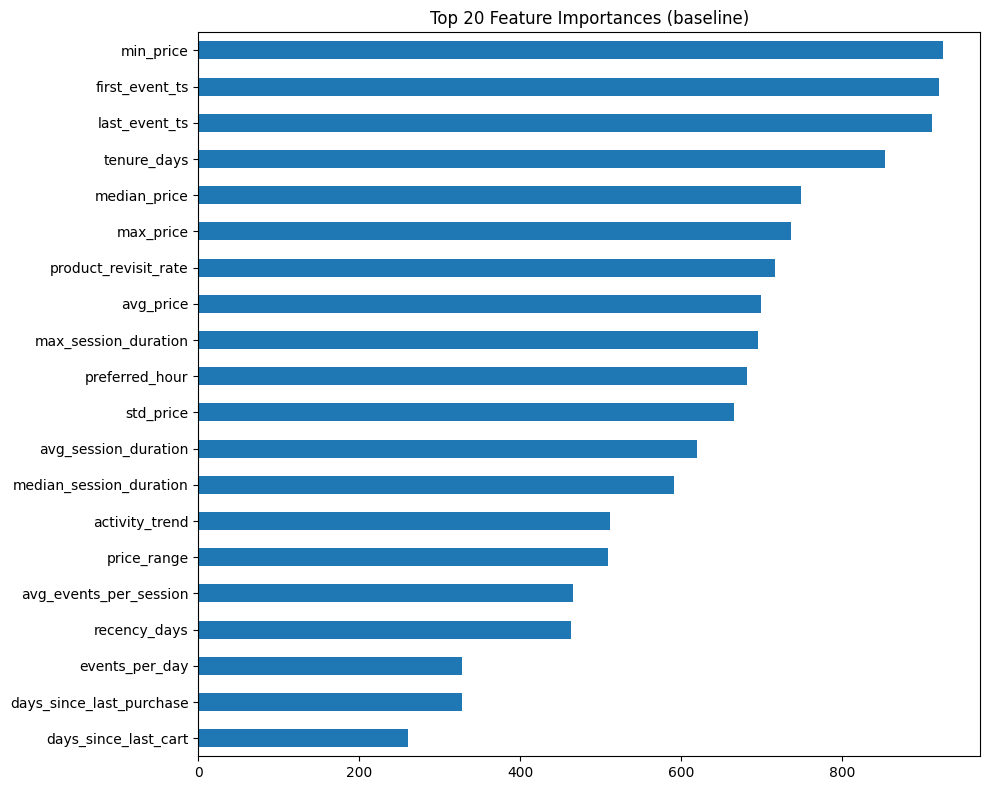


Top 10 features :
   1. min_price                      -> 925
   2. first_event_ts                 -> 920
   3. last_event_ts                  -> 911
   4. tenure_days                    -> 853
   5. median_price                   -> 749
   6. max_price                      -> 736
   7. product_revisit_rate           -> 717
   8. avg_price                      -> 699
   9. max_session_duration           -> 695
  10. preferred_hour                 -> 682


In [22]:
feat_imp = pd.Series(
    model_baseline.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind="barh", ax=ax)
ax.set_title("Top 20 Feature Importances (baseline)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f"  {i:2d}. {feat:30s} -> {imp}")


# 12. Modèle optimisé (RandomizedSearchCV)

On cherche les meilleurs hyperparamètres via cross-validation.
On utilise `average_precision` (= PR AUC) comme scoring car c'est la métrique
la plus adaptée aux problèmes très déséquilibrés.


In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1, 0.15],
    "num_leaves":        [20, 31, 40, 60, 80],
    "max_depth":         [-1, 5, 8, 12],
    "min_child_samples": [20, 50, 100],
    "subsample":         [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":  [0.7, 0.8, 0.9, 1.0],
    "reg_alpha":         [0, 0.1, 1.0],
    "reg_lambda":        [0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    lgb.LGBMClassifier(
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=-1,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="average_precision",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)
print(f"\nBest PR AUC (CV) : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best PR AUC (CV) : 0.2144
Best params : {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 20, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 12, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [24]:
# Evaluer le meilleur modele sur le test set
best_model = search.best_estimator_

y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best  = (y_proba_best >= 0.5).astype(int)

roc_best = roc_auc_score(y_test, y_proba_best)
pr_best  = average_precision_score(y_test, y_proba_best)
rec_best = recall_score(y_test, y_pred_best)

print("=== OPTIMIZED MODEL ===")
print(f"ROC AUC     : {roc_best:.4f}")
print(f"PR AUC      : {pr_best:.4f}")
print(f"Recall @0.5 : {rec_best:.4f}")
print()
print(classification_report(y_test, y_pred_best))
print()
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_best))


=== OPTIMIZED MODEL ===
ROC AUC     : 0.7971
PR AUC      : 0.2249
Recall @0.5 : 0.6700

              precision    recall  f1-score   support

           0       0.99      0.81      0.89     73443
           1       0.10      0.67      0.17      2218

    accuracy                           0.81     75661
   macro avg       0.54      0.74      0.53     75661
weighted avg       0.96      0.81      0.87     75661


Confusion matrix :
[[59637 13806]
 [  732  1486]]


# 13. Optimisation du seuil de décision

Le seuil par défaut de 0.5 n'est souvent pas optimal avec des classes déséquilibrées.
On cherche le seuil qui maximise le **F1-score** (compromis precision/recall).

**Comment ça marche :**
- `precision_recall_curve` calcule precision et recall pour chaque seuil possible
- On calcule le F1 = 2 × (P × R) / (P + R) pour chacun
- Le seuil avec le meilleur F1 est notre seuil optimal


In [25]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

# Calculer F1 pour chaque seuil
# Note : precisions et recalls ont 1 element de plus que thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Meilleur seuil : {best_threshold:.3f}")
print(f"F1 a ce seuil  : {best_f1:.4f}")
print(f"Precision       : {precisions[best_idx]:.4f}")
print(f"Recall          : {recalls[best_idx]:.4f}")


Meilleur seuil : 0.833
F1 a ce seuil  : 0.2720
Precision       : 0.2699
Recall          : 0.2741


In [26]:
# Appliquer le seuil optimise
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)

print(f"=== AVEC SEUIL OPTIMISE ({best_threshold:.3f}) ===")
print()
print(classification_report(y_test, y_pred_tuned))
print()
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_tuned))


=== AVEC SEUIL OPTIMISE (0.833) ===

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     73443
           1       0.27      0.27      0.27      2218

    accuracy                           0.96     75661
   macro avg       0.62      0.63      0.62     75661
weighted avg       0.96      0.96      0.96     75661


Confusion matrix :
[[71798  1645]
 [ 1610   608]]


# 14. Visualisations

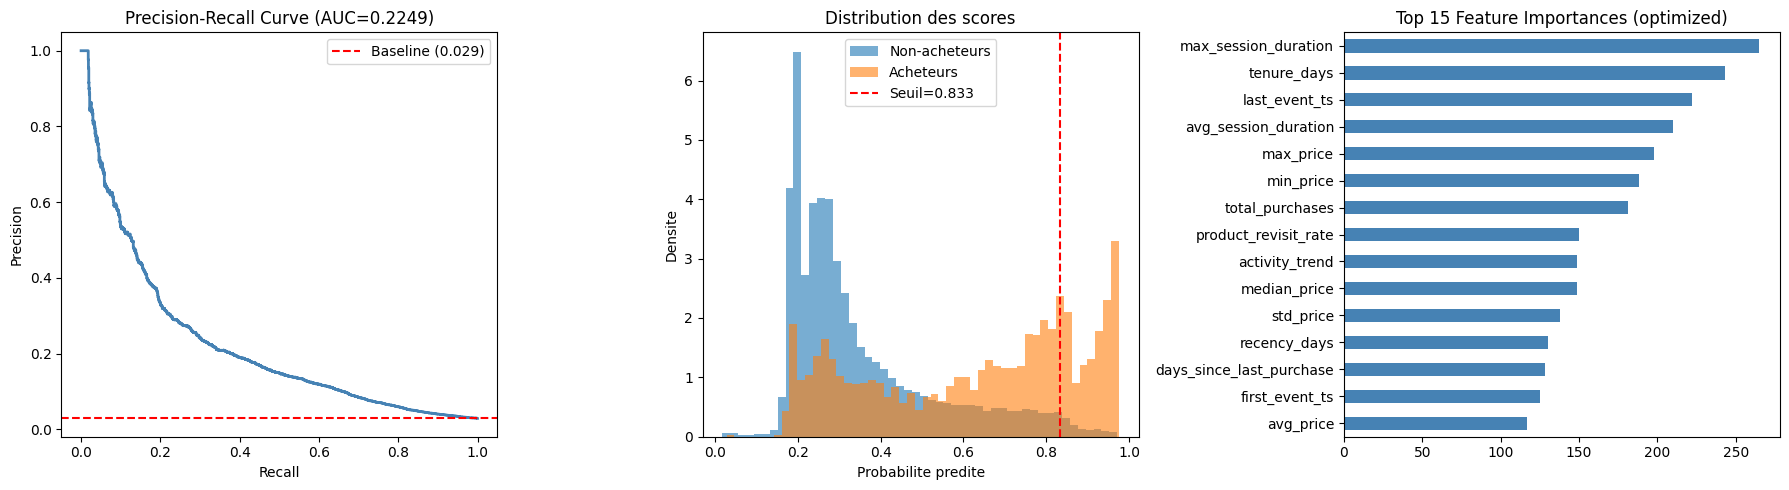

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PR Curve
axes[0].plot(recalls, precisions, color="steelblue", lw=2)
axes[0].axhline(y=y_test.mean(), color="red", linestyle="--",
                label=f"Baseline ({y_test.mean():.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (AUC={pr_best:.4f})")
axes[0].legend()

# 2. Distribution des probabilites predites
axes[1].hist(y_proba_best[y_test==0], bins=50, alpha=0.6,
             label="Non-acheteurs", density=True)
axes[1].hist(y_proba_best[y_test==1], bins=50, alpha=0.6,
             label="Acheteurs", density=True)
axes[1].axvline(x=best_threshold, color="red", linestyle="--",
                label=f"Seuil={best_threshold:.3f}")
axes[1].set_xlabel("Probabilite predite")
axes[1].set_ylabel("Densite")
axes[1].set_title("Distribution des scores")
axes[1].legend()

# 3. Feature importance (best model)
feat_imp_best = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=True)
feat_imp_best.tail(15).plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 15 Feature Importances (optimized)")

plt.tight_layout()
plt.show()


# 15. Learning Curves

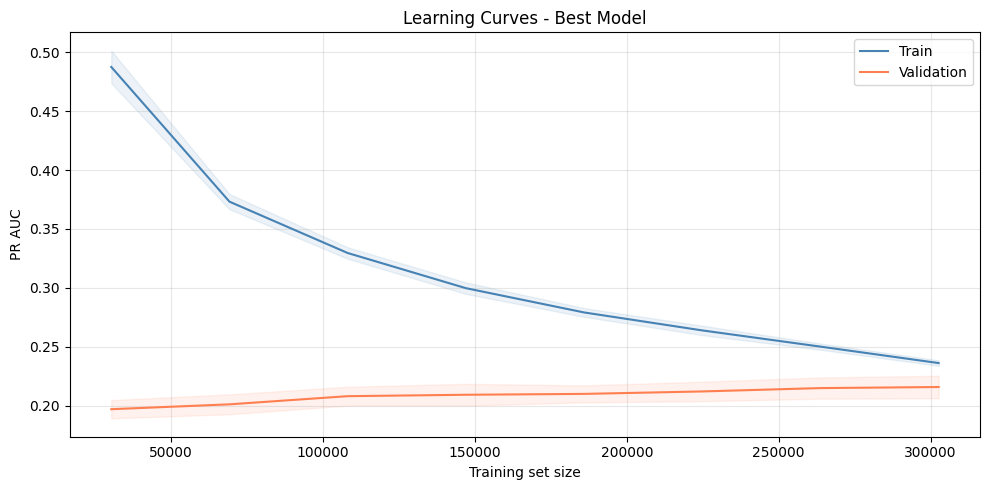

Train PR AUC (full) : 0.2361
Val PR AUC (full)   : 0.2157
Gap                 : 0.0203


In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, label="Train", color="steelblue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.1, color="steelblue")
plt.plot(train_sizes, val_mean, label="Validation", color="coral")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.1, color="coral")
plt.xlabel("Training set size")
plt.ylabel("PR AUC")
plt.title("Learning Curves - Best Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Train PR AUC (full) : {train_mean[-1]:.4f}")
print(f"Val PR AUC (full)   : {val_mean[-1]:.4f}")
print(f"Gap                 : {train_mean[-1] - val_mean[-1]:.4f}")


# 16. Résumé des résultats

In [29]:
print("=" * 60)
print("RESUME DES PERFORMANCES")
print("=" * 60)
print(f"{'Metrique':<25} {'Baseline':>12} {'Optimise':>12}")
print("-" * 60)
print(f"{'ROC AUC':<25} {roc_base:>12.4f} {roc_best:>12.4f}")
print(f"{'PR AUC':<25} {pr_base:>12.4f} {pr_best:>12.4f}")
print(f"{'Recall @0.5':<25} {rec_base:>12.4f} {rec_best:>12.4f}")
print(f"{'Recall @seuil optimal':<25} {'---':>12} {recalls[best_idx]:>12.4f}")
print(f"{'Seuil optimal':<25} {'0.500':>12} {best_threshold:>12.3f}")
print("=" * 60)
print()
print(f"Nombre de features : {X.shape[1]}")
print(f"Taille du dataset  : {len(X):,} users")
print(f"Taux de positifs   : {y.mean()*100:.2f}%")


RESUME DES PERFORMANCES
Metrique                      Baseline     Optimise
------------------------------------------------------------
ROC AUC                         0.7655       0.7971
PR AUC                          0.2043       0.2249
Recall @0.5                     0.5307       0.6700
Recall @seuil optimal              ---       0.2741
Seuil optimal                    0.500        0.833

Nombre de features : 39
Taille du dataset  : 378,301 users
Taux de positifs   : 2.93%


## Repères d'interprétation

| PR AUC | Interprétation |
|--------|---------------|
| < 0.05 | Pas mieux que le hasard |
| 0.05 - 0.15 | Signal faible mais présent |
| 0.15 - 0.30 | Bon modèle pour ce type de problème |
| > 0.30 | Très bon — vérifier qu'il n'y a pas de leakage |
| ~1.0 | Leakage certain |

Le **ROC AUC** sera naturellement plus élevé (souvent > 0.80) car il est moins sensible
au déséquilibre de classes. Le **PR AUC** est la métrique la plus honnête ici.


## Pistes d'amélioration

1. **Plus de données** : charger tout le fichier au lieu de 10M lignes
2. **Période d'observation plus longue** : utiliser aussi le fichier de novembre
3. **Features cross-catégories** : interactions entre catégories préférées et tendances
4. **Features séquentielles** : patterns de navigation (view → cart dans la même session)
5. **Embeddings produit** : encoder les product_id fréquents en features denses
6. **Stacking** : combiner LightGBM avec un autre modèle (XGBoost, CatBoost)
